In [1]:
import numpy as np
import pandas as pd
%matplotlib Inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
sns.set_style("whitegrid")

In [2]:
df=pd.read_csv("WineQT.csv")

In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [4]:
df.shape

(1143, 13)

In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

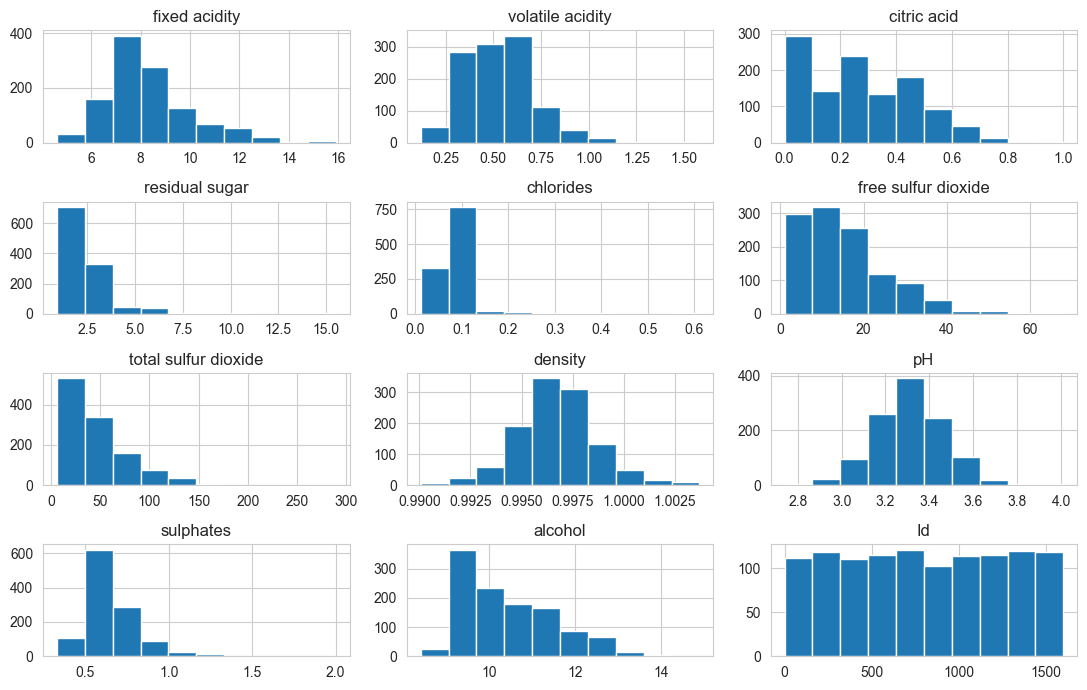

In [5]:
df.drop(columns="quality").hist(figsize=(11, 7))
plt.tight_layout()
plt.savefig("01_feature_distributions.pdf")
plt.show()




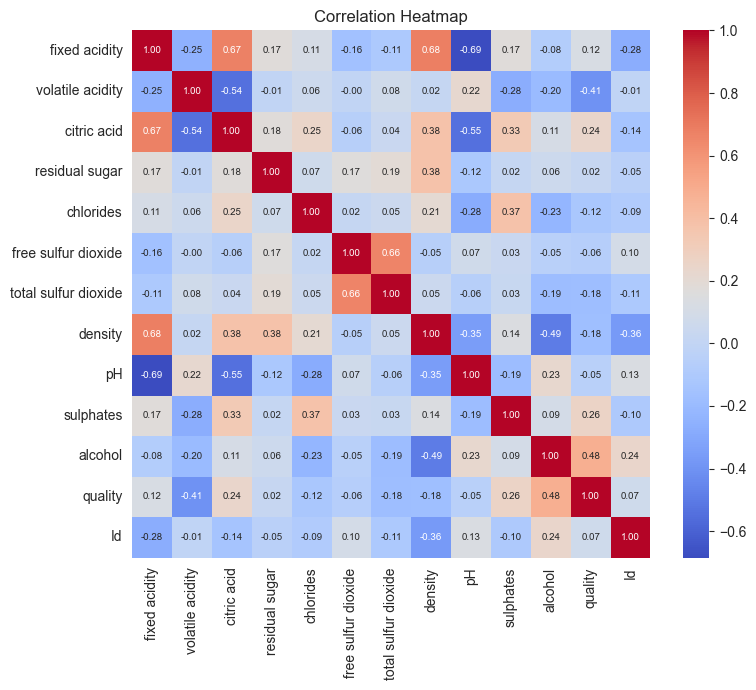

In [9]:
plt.figure(figsize=(8, 7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.pdf")
plt.show()

In [10]:
counts= df["quality"].value_counts().sort_index()

In [6]:
df["quality_tier"] = pd.cut(df["quality"], bins=[0, 4, 6, 10], labels=["low", "medium", "high"])
print("Tier distribution:\n", df["quality_tier"].value_counts())

Tier distribution:
 quality_tier
medium    945
high      159
low        39
Name: count, dtype: int64


In [7]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_tier
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,medium
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,medium
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,medium
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,medium
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,medium
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,medium
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,medium
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,medium


In [8]:
X = df.drop(columns=["quality", "quality_tier"])
y = df["quality_tier"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)
print("\nRandomForest")
print(f"Accuracy: {rf_accuracy:.3f}")
print(classification_report(y_test, rf_preds, zero_division=0))


RandomForest
Accuracy: 0.869
              precision    recall  f1-score   support

        high       0.69      0.56      0.62        32
         low       0.00      0.00      0.00         8
      medium       0.89      0.96      0.92       189

    accuracy                           0.87       229
   macro avg       0.53      0.51      0.51       229
weighted avg       0.83      0.87      0.85       229



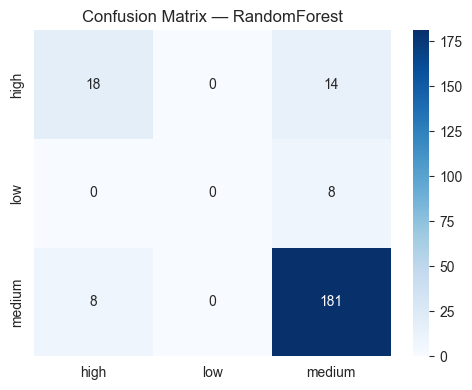

In [25]:

rf_cm = confusion_matrix(y_test, rf_preds, labels=rf_model.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Confusion Matrix — RandomForest")
plt.tight_layout()
plt.savefig("cm_RandomForest.pdf")
plt.show()

In [24]:
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)
sgd_preds = sgd_model.predict(X_test)
sgd_accuracy = accuracy_score(y_test, sgd_preds)

print("\nSGD")
print(f"Accuracy: {sgd_accuracy:.3f}")
print(classification_report(y_test, sgd_preds, zero_division=0))


SGD
Accuracy: 0.131
              precision    recall  f1-score   support

        high       0.20      0.12      0.15        32
         low       0.04      0.88      0.07         8
      medium       0.95      0.10      0.18       189

    accuracy                           0.13       229
   macro avg       0.40      0.37      0.14       229
weighted avg       0.81      0.13      0.17       229



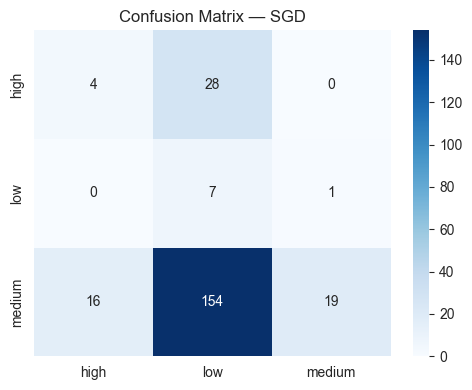

In [23]:
sgd_cm = confusion_matrix(y_test, sgd_preds, labels=sgd_model.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(sgd_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sgd_model.classes_, yticklabels=sgd_model.classes_)
plt.title("Confusion Matrix — SGD")
plt.tight_layout()
plt.savefig("cm_SGD.pdf")
plt.show()

In [21]:
svc_model = SVC()
svc_model.fit(X_train, y_train)
svc_preds = svc_model.predict(X_test)
svc_accuracy = accuracy_score(y_test, svc_preds)

print("\nSVC ")
print(f"Accuracy: {svc_accuracy:.3f}")
print(classification_report(y_test, svc_preds, zero_division=0))


SVC 
Accuracy: 0.825
              precision    recall  f1-score   support

        high       0.00      0.00      0.00        32
         low       0.00      0.00      0.00         8
      medium       0.83      1.00      0.90       189

    accuracy                           0.83       229
   macro avg       0.28      0.33      0.30       229
weighted avg       0.68      0.83      0.75       229



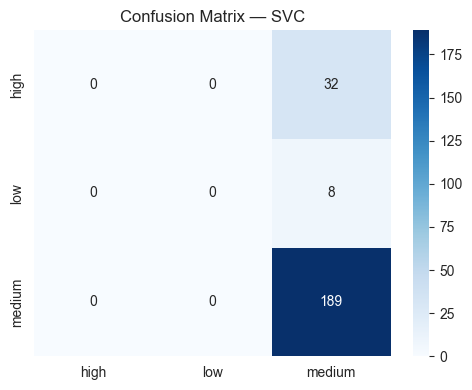

In [22]:
svc_cm = confusion_matrix(y_test, svc_preds, labels=svc_model.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(svc_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=svc_model.classes_, yticklabels=svc_model.classes_)
plt.title("Confusion Matrix — SVC")
plt.tight_layout()
plt.savefig("cm_SVC.pdf")
plt.show()


In [28]:
comparison = pd.DataFrame([
    {"Model": "RandomForest", "Accuracy": round(rf_accuracy, 3)},
    {"Model": "SGD", "Accuracy": round(sgd_accuracy, 3)},
    {"Model": "SVC", "Accuracy": round(svc_accuracy, 3)},
])
print("\n MODEL COMPARISON ")
print(comparison)

if rf_accuracy >= sgd_accuracy and rf_accuracy >= svc_accuracy:
    best_name, best_acc = "RandomForest", rf_accuracy
elif sgd_accuracy >= svc_accuracy:
    best_name, best_acc = "SGD", sgd_accuracy
else:
    best_name, best_acc = "SVC", svc_accuracy

print(f"\nConclusion: {best_name} is most suitable for deployment; highest "
      f"accuracy ({best_acc:.3f}), and (for Random Forest) gives interpretable "
      f"feature importances useful for explaining predictions to stakeholders.")

print("\nWine quality prediction complete.")



 MODEL COMPARISON 
          Model  Accuracy
0  RandomForest     0.869
1           SGD     0.131
2           SVC     0.825

Conclusion: RandomForest is most suitable for deployment; highest accuracy (0.869), and (for Random Forest) gives interpretable feature importances useful for explaining predictions to stakeholders.

Wine quality prediction complete.
